Manipulating fruitfly gut images for segmentation

In [5]:
import cv2
import numpy as np


def polygon_selection(image, overlay=None, display_size=1024, overlay_alpha=0.4):
    """
    Allow user to select a polygon region by clicking points.
    Press 'c' to complete the selection.
    The image is resized for display, but the mask is created on the original resolution.

    Args:
        image: Original image (can be any size)
        overlay: Optional 2D mask to overlay (same HxW as image)
        display_size: Target size for display (default 1024)
        overlay_alpha: Overlay transparency (0..1)
    """
    # Store original dimensions
    original_h, original_w = image.shape[:2]

    # Calculate scaling factor to fit within display_size while maintaining aspect ratio
    scale = min(display_size / original_w, display_size / original_h)
    new_w = int(original_w * scale)
    new_h = int(original_h * scale)

    # Make a copy and normalize for display
    draw_image = image.copy()
    p_low, p_high = np.percentile(draw_image, [0, 99])  # Clip top 1%
    draw_image = np.clip(draw_image, p_low, p_high)
    draw_image = cv2.normalize(draw_image, None, 0, 255, cv2.NORM_MINMAX).astype(
        np.uint8
    )

    # If overlay provided, blend it in red
    if overlay is not None:
        overlay_u8 = np.clip(overlay, 0, 255).astype(np.uint8)
        base_bgr = cv2.cvtColor(draw_image, cv2.COLOR_GRAY2BGR)
        red = np.zeros_like(base_bgr)
        red[..., 2] = overlay_u8
        draw_image = cv2.addWeighted(base_bgr, 1.0, red, overlay_alpha, 0)
    else:
        draw_image = cv2.cvtColor(draw_image, cv2.COLOR_GRAY2BGR)

    # Resize for display
    draw_image_resized = cv2.resize(
        draw_image, (new_w, new_h), interpolation=cv2.INTER_LINEAR
    )

    points = []

    # Mouse callback function
    def draw_polygon(event, x, y, flags, param):
        nonlocal draw_image_resized

        # Left button click - add point
        if event == cv2.EVENT_LBUTTONDOWN:
            points.append((x, y))
            # Draw a small circle at clicked point
            cv2.circle(
                draw_image_resized,
                center=(x, y),
                radius=3,
                color=(255, 255, 0),
                thickness=-1,
            )

            # Connect lines between points
            if len(points) > 1:
                cv2.line(
                    draw_image_resized,
                    points[-2],
                    points[-1],
                    thickness=1,
                    color=(255, 0, 0),
                )

            # Show the image with selected points
            cv2.imshow("Select Polygon - Press C when done", draw_image_resized)

    # Create window and set mouse callback
    cv2.imshow("Select Polygon - Press C when done", draw_image_resized)
    cv2.setMouseCallback("Select Polygon - Press C when done", draw_polygon)

    # Wait for key press
    while True:
        key = cv2.waitKey(1) & 0xFF
        if key == ord("c"):  # Press 'c' to complete
            break

    # Close the window
    cv2.destroyAllWindows()

    # Create mask from polygon if we have enough points
    if len(points) > 2:
        # Scale points back to original image coordinates
        points_original = [(int(x / scale), int(y / scale)) for x, y in points]

        # Create mask on original image dimensions
        mask = np.zeros((original_h, original_w), dtype=np.uint8)
        points_array = np.array([points_original], dtype=np.int32)
        cv2.fillPoly(mask, points_array, 255)

        # Apply mask to extract region from original image
        result = cv2.bitwise_and(image, image, mask=mask)

        # Get bounding box of non-zero region (for cropping)
        x, y, w, h = cv2.boundingRect(mask)
        cropped = result[y : y + h, x : x + w]

        return mask, result, cropped
    else:
        print("Not enough points selected for polygon")
        return None, None, None

In [42]:
import os
import tifffile
from imaris_ims_file_reader import ims
import numpy as np
from scipy.ndimage import binary_fill_holes, gaussian_filter, find_objects

main_dir = (
    r"C:\Users\6331823\Local SSD\Data_Miriam\20240312"
)

for input_dir in os.listdir(main_dir):
    input_dir = os.path.join(main_dir, input_dir)
    if os.path.isdir(input_dir):
        for file in os.listdir(input_dir):
            if file.endswith(".ims"):
                file_name = os.path.splitext(file)[0]
                image = ims(os.path.join(input_dir, file))
                esg = image[:,0]
                esg_max =np.max(esg, axis=0)
                print(esg.shape, esg_max.shape)
                segmentation = image[:,4]
                # segmentation: shape (Z, Y, X) with integer labels
                # segmentation: shape (Z, Y, X) with integer labels
                segmentation = segmentation.astype(np.uint16)
                segmentation_filled = np.zeros_like(segmentation, dtype=np.uint16)

                # Compute bounding boxes per label (label IDs must be 1..N)
                slices = find_objects(segmentation)

                for lab, slc in enumerate(slices, start=1):
                    if slc is None:
                        continue
                    sub = segmentation[slc]
                    mask = (sub == lab)
                    if not mask.any():
                        continue

                    filled = binary_fill_holes(mask)
                    smoothed = gaussian_filter(filled.astype(np.float32), sigma=(1, 2, 2))
                    segmentation_filled[slc][smoothed > 0.3] = lab

                segmentation_max = np.max(segmentation, axis=0)
                segmentation_bright = np.where(segmentation_max > 0, 255, 0)

                # Get polygon selection
                selected_mask, _, _ = polygon_selection(
                    esg_max, overlay=segmentation_bright, overlay_alpha=1
                )

                while selected_mask.ndim < esg_max.ndim:
                    selected_mask = np.expand_dims(selected_mask, axis=0)
                # Apply mask to original projXY
                organoid_only = np.where(selected_mask > 0, esg_max, 0)

                # Find the XY coordinates of the mask
                selected_mask = np.squeeze(selected_mask)  # Should be (Y, X)
                maskXY = selected_mask > 0
                coordsXY = np.where(maskXY)

                # Adjust cropping limits based on XY projection, creating a bounding box around the organoid
                if coordsXY[0].size > 0:
                    row_min, row_max = (
                        np.min(coordsXY[0]),
                        np.max(coordsXY[0]) + 1,
                    )
                    col_min, col_max = (
                        np.min(coordsXY[1]),
                        np.max(coordsXY[1]) + 1,
                    )

                cropped_image = image[:, :, :, row_min:row_max, col_min:col_max]  # (Z, C, Y, X)

                # add filled segmentation as additional channel
                segmentation_cropped = segmentation_filled[:, row_min:row_max, col_min:col_max]  # (Z, Y, X)
                segmentation_cropped = segmentation_cropped[:, None, :, :]  # (Z, 1, Y, X)
                segmentation_cropped = np.transpose(
                    segmentation_cropped, (1, 0, 2, 3))
                print(cropped_image.shape, segmentation_cropped.shape)

                cropped_image = np.concatenate((cropped_image, segmentation_cropped), axis=0)  # (Z, C+1, Y, X)

                # On this cropped frame, we again need to make it so that the pixels in the corners where no organoid is are actually black
                mask_crop = maskXY[row_min:row_max, col_min:col_max]  # shape: (Y_crop, X_crop)
                # Expand mask to 4D: (C, Z, Y_crop, X_crop)
                mask_expanded = mask_crop[np.newaxis, np.newaxis, :, :]
                # Repeat over C and Z to match cropped_image shape
                mask_expanded = np.repeat(mask_expanded, cropped_image.shape[0], axis=0)  # C
                mask_expanded = np.repeat(mask_expanded, cropped_image.shape[1], axis=1)  # Z
                # Apply the mask
                cropped_image_masked = np.where(mask_expanded, cropped_image, 0).astype(np.uint16)

                cropped_image_masked = np.transpose(
                    cropped_image_masked, (1, 0, 2, 3)
                )  # Z C Y X for tiff

                # Save this final cropped frame in the output folder
                tifffile.imwrite(
                    os.path.join(input_dir, f"{file_name}_cropped.tif"),
                    cropped_image_masked,
                    imagej=True,
                    compression="zlib",
                    compressionargs={"level": 8},
                )

Opening readonly file: C:\Users\6331823\Local SSD\Data_Miriam\20240312\20240312_DFSts x w1118 +Bleo_1-1\20240312_DFSts x w1118 +Bleo_1-1.ims 

Closing file: C:\Users\6331823\Local SSD\Data_Miriam\20240312\20240312_DFSts x w1118 +Bleo_1-2\20240312_DFSts x w1118 +Bleo_1-2.ims 

(35, 1024, 1024) (1024, 1024)
(5, 35, 1000, 711) (1, 35, 1000, 711)
Opening readonly file: C:\Users\6331823\Local SSD\Data_Miriam\20240312\20240312_DFSts x w1118 +Bleo_1-2\20240312_DFSts x w1118 +Bleo_1-2.ims 

Closing file: C:\Users\6331823\Local SSD\Data_Miriam\20240312\20240312_DFSts x w1118 +Bleo_1-1\20240312_DFSts x w1118 +Bleo_1-1.ims 

(25, 1930, 1935) (1930, 1935)
(5, 25, 1299, 734) (1, 25, 1299, 734)
Opening readonly file: C:\Users\6331823\Local SSD\Data_Miriam\20240312\20240312_DFSts x w1118 +Bleo_1-3\20240312_DFSts x w1118 +Bleo_1-3.ims 

Closing file: C:\Users\6331823\Local SSD\Data_Miriam\20240312\20240312_DFSts x w1118 +Bleo_1-2\20240312_DFSts x w1118 +Bleo_1-2.ims 

(35, 1024, 1024) (1024, 1024)
(5,

In [51]:
training_dir = r"C:\Users\6331823\Local SSD\Data_Miriam\20240312\Model"
main_dir = r"C:\Users\6331823\Local SSD\Data_Miriam\20240312"


for_training = [
    "20240312_DFSts x w1118 +Bleo_1-1",
    "20240312_DFSts x w1118 +Bleo_1-2",
    "20240312_DFSts x w1118_1-2",
    "20240312_DFSts x w1118_1-3",
    "20240312_DFSts x w1118_2-1",
]

for folder in for_training:
    input_directory = os.path.join(main_dir, folder)
    image = tifffile.imread(
        os.path.join(input_directory, f"{folder}_cropped.tif")
    )
    esg = image[:, 0, :, :]  # Z Y X
    segmentation = image[:, 5, :, :]  # Z Y X
    count = 0
    # select 5 random integers between 0 and esg.shape[0]-1
    selected_slices = np.random.choice(esg.shape[0], size=20, replace=False)
    for slice in selected_slices:
        if count >= 10:
            break
        if len(np.unique(segmentation[slice, :, :])) < 5:
            continue
        count += 1
        tifffile.imwrite(
            os.path.join(
                training_dir, f"{folder}_slice_{slice}_esg.tif"
            ),
            esg[slice, :, :],
            imagej=True,
        )
        tifffile.imwrite(
            os.path.join(
                training_dir, f"{folder}_slice_{slice}_mask.tif"
            ),
            segmentation[slice, :, :],
            imagej=True,
        )

In [52]:
from cellpose import io, models, train

io.logger_setup()

training_dir = r"C:\Users\6331823\Local SSD\Data_Miriam\20240312\Model"

output = io.load_train_test_data(
    training_dir,
    image_filter="_esg",
    mask_filter="_mask",
    look_one_level_down=False,
)
images, labels, image_names, test_images, test_labels, image_names_test = output

model = models.CellposeModel(gpu=True)

model_path, train_losses, test_losses = train.train_seg(
    model.net,
    train_data=images,
    train_labels=labels,
    test_data=test_images,
    test_labels=test_labels,
    weight_decay=0.1,
    learning_rate=1e-5,
    n_epochs=100,
    model_name="esg_fruitfly",
)

creating new log file
2026-02-03 14:53:52,035 [INFO] WRITING LOG OUTPUT TO C:\Users\6331823\.cellpose\run.log
2026-02-03 14:53:52,036 [INFO] 
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.11.13 
torch version:  	2.8.0+cu128
2026-02-03 14:53:52,092 [INFO] not all flows are present, running flow generation for all images
2026-02-03 14:53:52,704 [INFO] 50 / 50 images in C:\Users\6331823\Local SSD\Data_Miriam\20240312\Model folder have labels
2026-02-03 14:53:52,712 [INFO] ** TORCH CUDA version installed and working. **
2026-02-03 14:53:52,712 [INFO] >>>> using GPU (CUDA)
2026-02-03 14:53:53,708 [INFO] >>>> loading model C:\Users\6331823\.cellpose\models\cpsam
2026-02-03 14:53:54,125 [INFO] computing flows for labels


100%|██████████| 50/50 [00:01<00:00, 31.28it/s]

2026-02-03 14:53:55,759 [INFO] >>> computing diameters



100%|██████████| 50/50 [00:00<00:00, 435.36it/s]

2026-02-03 14:53:55,889 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-02-03 14:53:56,411 [INFO] >>> n_epochs=100, n_train=50, n_test=None
2026-02-03 14:53:56,411 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.10000
2026-02-03 14:53:56,411 [INFO] >>> saving model to c:\Users\6331823\Local SSD\Coding projects\organoid_segmenter\miscellaneous\models\esg_fruitfly
2026-02-03 14:54:02,173 [INFO] 0, train_loss=0.2170, test_loss=0.0000, LR=0.000000, time 5.76s
2026-02-03 14:54:29,993 [INFO] 5, train_loss=0.2935, test_loss=0.0000, LR=0.000006, time 33.58s
2026-02-03 14:54:57,778 [INFO] 10, train_loss=0.2145, test_loss=0.0000, LR=0.000010, time 61.37s
2026-02-03 14:55:52,989 [INFO] 20, train_loss=0.1058, test_loss=0.0000, LR=0.000010, time 116.58s
2026-02-03 14:56:48,551 [INFO] 30, train_loss=0.0745, test_loss=0.0000, LR=0.000010, time 172.14s
2026-02-03 14:57:43,921 [INFO] 40, train_loss=0.0659, test_loss=0.0000, LR=0.000010, time 227.51s
2026-02-03 14:58:41,141 [INFO] 50, train_loss=0.0518, test_loss=0.0000, LR=0.000005, time 284.73s
2026-02-03 14:

In [2]:
import numpy as np
from skimage.measure import regionprops


def centroid_accuracy(ground_truth_mask, predicted_mask):
    ground_truth_mask = np.asarray(ground_truth_mask)
    predicted_mask = np.asarray(predicted_mask)
    if ground_truth_mask.shape != predicted_mask.shape:
        raise ValueError("Masks must share shape")

    gt_props = regionprops(ground_truth_mask)
    hit_pred_labels = set()
    predicted_labels = np.array([])
    tp = fn = 0

    for prop in gt_props:
        centroid = np.rint(prop.centroid).astype(int)
        centroid = tuple(np.clip(centroid, 0, np.array(ground_truth_mask.shape) - 1))
        pred_label = predicted_mask[centroid]
        predicted_labels = np.append(predicted_labels, pred_label)
        if pred_label > 0:
            tp += 1
            hit_pred_labels.add(int(pred_label))
        else:
            fn += 1

    pred_labels = set(np.unique(predicted_mask))
    pred_labels.discard(0)
    fp = len(pred_labels - hit_pred_labels)
    fp_list = list(pred_labels - hit_pred_labels)
    merged_cells = len(predicted_labels) - len(np.unique(predicted_labels))

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if precision + recall else 0.0

    gt_binary = ground_truth_mask > 0
    pred_binary = predicted_mask > 0
    intersection = np.count_nonzero(gt_binary & pred_binary)
    dice = (
        (2 * intersection) / (gt_binary.sum() + pred_binary.sum())
        if (gt_binary.sum() + pred_binary.sum())
        else 0.0
    )

        # Calculate 3D IoU
    union = np.count_nonzero(gt_binary | pred_binary)
    # iou_3d = (
    #     intersection / union
    #     if union > 0
    #     else 0.0
    # )

    return {
        "true_positives": tp,
        "false_negatives": fn,
        "false_positives": fp,
        "merged_cells": merged_cells,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "voxel_dice": dice,
        "iou_3d": iou_3d,
        "false_positive_labels": fp_list,
    }


In [72]:
import sys
import napari

sys.path.insert(0, os.path.dirname(os.getcwd()))
import utils

fruitfly = "20240312_DFSts x w1118 +Bleo_1-3"
model_path = r"C:\Users\6331823\Local SSD\Data_Miriam\20240312\Model\esg_fruitfly"
main_dir = r"C:\Users\6331823\Local SSD\Data_Miriam\20240312"
input_dir = os.path.join(main_dir, fruitfly)

# model = utils.load_model(model_path)

image = tifffile.imread(os.path.join(input_dir, f"{fruitfly}_cropped.tif"))
esg = image[:, 0, :, :]  # Z Y X
nre = image[:, 1, :, :]  # Z Y X
gt = image[:, 4, :, :]  # Z Y X
polished_gt = image[:, 5, :, :]  # Z Y X
# seg_stack = utils.segment(esg, model)
# tifffile.imwrite(
#     os.path.join(input_dir, f"{fruitfly}_segmentation_2d.tif"),
#     seg_stack,
#     imagej=True,
#     compression="zlib",
#     compressionargs={"level": 8},
# )
seg_stack = tifffile.imread(
    os.path.join(input_dir, f"{fruitfly}_segmentation_2d.tif")
)
seg_stack_stitched, _ = utils.stitch_3d(seg_stack, image1=esg)
tifffile.imwrite(
    os.path.join(input_dir, f"{fruitfly}_segmentation_3d.tif"),
    seg_stack_stitched,
    imagej=True,
    compression="zlib",
    compressionargs={"level": 8},
)

results = centroid_accuracy(polished_gt, seg_stack_stitched)
print(results)

viewer = napari.Viewer()
scale = (2, 0.568, 0.568)
viewer.add_image(esg, name="esg", scale=scale)
viewer.add_image(nre, name="nre", scale=scale)
viewer.add_labels(gt, name="gt", scale=scale)
viewer.add_labels(polished_gt, name="gt_polished", scale=scale)
viewer.add_labels(seg_stack, name="predicted_segmentation_raw", scale=scale)
viewer.add_labels(seg_stack_stitched, name="predicted_segmentation", scale=scale)

Starting 3D stitching process...
Initial organoid has 4542 2d sliced cells.
Starting IOU based 3D stitching...
Completed IOU based stitching: 1362 cells formed.
Starting iterative breaking of cells
    Iteration 1: Made 16 breaks.
Starting to split touching cells...
Found 299 pairs of touching cells.
Splitted 12 touching cell pairs.
Stitching cells with 2 or fewer slices...
Stitched 8 small cells, and removed 207 cells without suitable neighbors.
Final stitched mask has 1163 cells.
{'true_positives': 780, 'false_negatives': 146, 'false_positives': 440, 'merged_cells': 202, 'precision': 0.639344262295082, 'recall': 0.8423326133909287, 'f1': 0.7269338303821063, 'voxel_dice': 0.5397845298031898, 'false_positive_labels': [1, 16, 18, 44, 58, 78, 84, 89, 97, 114, 133, 141, 143, 181, 182, 183, 184, 191, 200, 201, 220, 227, 234, 256, 261, 264, 266, 267, 269, 270, 271, 272, 277, 280, 288, 289, 290, 297, 304, 335, 348, 349, 355, 357, 358, 359, 362, 363, 364, 365, 368, 370, 371, 422, 428, 435, 43

<Labels layer 'predicted_segmentation' at 0x26a1780ab90>

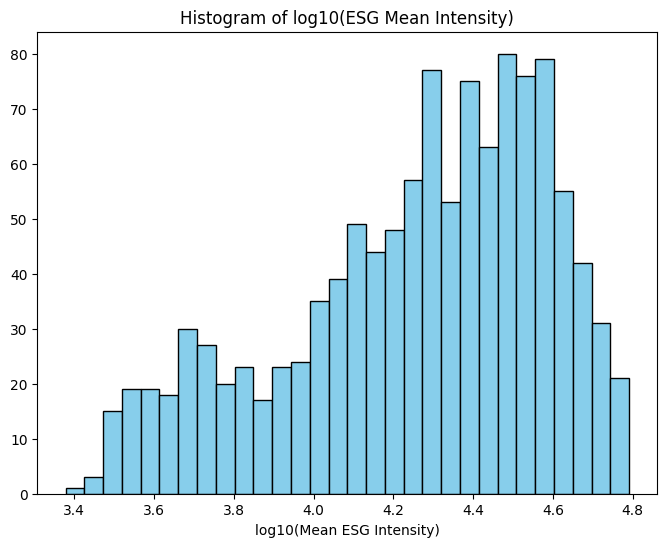

In [71]:
from skimage.measure import regionprops
import matplotlib.pyplot as plt

data = utils.properties_mask(seg_stack_stitched)
df_esg = utils.properties_channel(seg_stack_stitched,esg, type="esg")
df_nre = utils.properties_channel(seg_stack_stitched,image[:,1], type="nre")
data = data.merge(df_esg, on="label")
data = data.merge(df_nre, on="label")
data
# histogram of esg_mean values
vals = data["raw_nre"].to_numpy()
vals = vals[vals > 0]  # avoid log10(0)
vals_log10 = np.log10(vals)

plt.figure(figsize=(8, 6))
plt.hist(vals_log10, bins=30, color="skyblue", edgecolor="black")
plt.title("Histogram of log10(ESG Mean Intensity)")
plt.xlabel("log10(Mean ESG Intensity)")
plt.show()